# Code here

In [96]:
# imports
import pandas as pd
import numpy as np

# setting column specifications
colspecs = [
    (0, 5),
    (5, 8),
    (8, 15),
    (15, 20),
    (20, 28),
    (28, 36),
    (36, 44),
    (44, 52),
    (52, 60),
    (60, 68),
]

# setting names of columns
names = ["res_id", "res_name", "atom_name", "atom_id", "x", "y", "z", "Vx", "Vy", "Vz"]

# reading data
data = pd.read_fwf(
    "../../data/npt-HK4.gro",
    colspecs=colspecs,
    names=names,
    skiprows=2,
    skipfooter=1,
)

# Problem: after atom id 99999, it reverts back to 0. The following solves this:
for i in data.index:
    if i >= 99999:
        data.at[i, "atom_id"] += 100000

# reading Title, number of atoms and box_dimensions
with open("../../data/npt-HK4.gro", "rb") as f:
    title = f.readline().decode().strip()  # First line of .gro file
    num_atoms = f.readline().decode().strip()  # Second line of .gro file

    # Last line of file
    f.seek(-2, 2)
    while f.read(1) != b"\n":
        f.seek(-2, 1)
    box_dimensions = f.readline().decode().strip().split()
    box_dimensions = list(map(float, box_dimensions))


print(data.tail())
print(f"Title: {title}")
print(f"Number of atoms: {num_atoms}")
print(f"Box dimensions: {box_dimensions}")

        res_id res_name atom_name  atom_id      x      y      z      Vx  \
126079    1501      HK4       H23   126080  0.953  5.984  1.494 -1.2440   
126080    1501      HK4       C44   126081  0.736  6.009  1.525  0.1513   
126081    1501      HK4       H24   126082  0.707  6.041  1.425  0.3100   
126082    1501      HK4       C45   126083  0.632  5.988  1.615 -0.0110   
126083    1501      HK4       H25   126084  0.542  6.051  1.607 -0.7669   

            Vy      Vz  
126079  0.1068 -0.7226  
126080  0.5200  0.5632  
126081  2.4172  1.1123  
126082 -0.1637  0.2235  
126083 -0.9514  2.2265  
Title: mol only system in water
Number of atoms: 126084
Box dimensions: [11.24798, 11.24798, 11.24798]


In [97]:
O1 = data.loc[data["atom_name"] == "O1", ["x", "y", "z"]].reset_index(drop=True)
O2 = data.loc[data["atom_name"] == "O2", ["x", "y", "z"]].reset_index(drop=True)

#Checking for edge case
for i in O1.index:
    diff = np.ndarray.tolist(O1.subtract(O2).values[0])
    for x in diff:
        if x > 1:
            xyz = diff.index(x)
            match xyz:
                case 0:
                    O1.loc[i,'x'] = O1.at[i,'x'] - box_dimensions[xyz]
                case 1:
                    O1.loc[i,'y'] = O1.at[i,'y'] - box_dimensions[xyz]
                case 2:
                    O1.loc[i,'z'] = O1.at[i,'z'] - box_dimensions[xyz]
        elif x < -1:
            xyz = diff.index(x)
            match xyz:
                case 0:
                    O2.loc[i,'x'] = O2.at[i,'x'] - box_dimensions[xyz]
                case 1:
                    O2.loc[i,'y'] = O2.at[i,'y'] - box_dimensions[xyz]
                case 2:
                    O2.loc[i,'z'] = O2.at[i,'z'] - box_dimensions[xyz]

centre = O1.add(O2).abs().divide(2)
centre.insert(0,"res_id", data["res_id"].unique().astype(int))

# Nitrogen locations(FOR FUTURE USE)
# N1 = data.loc[data['atom_name'] == "N1",['x','y','z']].reset_index(drop=True)
# N2 = data.loc[data['atom_name'] == "N2",['x','y','z']].reset_index(drop=True)

In [98]:
# Make subboxes
## First, find dimension of one molecule to approximate number of subboxes needed
molecule_size = pd.DataFrame(columns=["res_id", "molecule_size"])
for n in range(1, 1502):
    one_molecule = data.loc[data["res_id"] == n, ["x", "y", "z"]]
    molecule_dimensions = (one_molecule.max() - one_molecule.min()).to_list()
    molecule_size.loc[n - 1] = [n, np.prod(molecule_dimensions)]

### My first attempt, but this is number of subboxes per axis, could be useful
# number_of_subboxes = [round(x / y) for x,y in zip(box_dimensions,molecule_dimensions)]
# number_of_subboxes

number_of_subboxes = round(np.prod(box_dimensions) / np.prod(molecule_dimensions))
## Output: number_of_subboxes = 142

## Subbox dimension = box_dimension/mol_dimension + some arbitrary constant to make it slightly bigger to lower chance of edge case where no molecule exist in a subbox
## Use the closest cube root(ie. 125)to provide a better approximation as well as to make calculations simpler

####LOGIC ERROR: WE USE 1501 SUBBOXES, BUT SINCE 1501 IS NOT A PERFECT CUBE, USE 1331 SINCE NEAREST PERFECT CUBE
number_of_subboxes = 1331
subboxes_dimensions = [x / number_of_subboxes ** (1 / 3) for x in box_dimensions]


In [99]:
""" csv file making
#import csv
with open('../../../../test.csv', 'w', newline = '') as csvfile:
    fieldname = ['index', 'count']
    writer = csv.DictWriter(csvfile, fieldnames=fieldname)
    for n in range(5,13):
        matrix = []
        empty_box = []
        subboxes_dimensions = [x / n  for x in box_dimensions]
        for i in range(1,n+1):
            for j in range(1,n+1):
                for k in range(1,n+1):
                    matrix.append([i,j,k])
        
        for (p, q, r) in matrix:
            molecule_in_subbox = centre.loc[
            (centre["x"] < subboxes_dimensions[0] * p)
            & (centre["y"] < subboxes_dimensions[1] * q)
            & (centre["z"] < subboxes_dimensions[2] * r)
            & (centre["x"] >= subboxes_dimensions[0] * (p-1))
            & (centre["y"] >= subboxes_dimensions[1] * (q-1))
            & (centre["z"] >= subboxes_dimensions[2] * (r-1))
            ]
            count = molecule_in_subbox["res_id"].count()
            empty_box.append({'index':[p,q,r], 'count': count})
    
        writer.writeheader()
        writer.writerows(empty_box)
"""

# Subdivide the box into subboxes and find what molecule exist in which subbox
matrix = []

n = round(number_of_subboxes ** (1 / 3))

for i in range(0, n + 2):
    for j in range(0, n + 2):
        for k in range(0, n + 2):
            matrix.append([i, j, k])

subbox = pd.DataFrame(columns=["index", "res_id", "x", "y", "z"])
iterate = 1
for p, q, r in matrix:
    molecule_in_subbox = centre.loc[
        (centre["x"] < subboxes_dimensions[0] * p)
        & (centre["y"] < subboxes_dimensions[1] * q)
        & (centre["z"] < subboxes_dimensions[2] * r)
        & (centre["x"] >= subboxes_dimensions[0] * (p - 1))
        & (centre["y"] >= subboxes_dimensions[1] * (q - 1))
        & (centre["z"] >= subboxes_dimensions[2] * (r - 1))
    ]

    subbox.loc[iterate] = {
        "index": (p, q, r),
        "res_id": molecule_in_subbox["res_id"].values,
        "x": molecule_in_subbox["x"].values,
        "y": molecule_in_subbox["y"].values,
        "z": molecule_in_subbox["z"].values,
    }
    iterate += 1

subbox

,index,res_id,x,y,z
1,"(0, 0, 0)",[],[],[],[]
2,"(0, 0, 1)",[],[],[],[]
3,"(0, 0, 2)",[],[],[],[]
4,"(0, 0, 3)",[],[],[],[]
5,"(0, 0, 4)",[],[],[],[]
...,...,...,...,...,...
2193,"(12, 12, 8)",[],[],[],[]
2194,"(12, 12, 9)",[],[],[],[]
2195,"(12, 12, 10)",[],[],[],[]
2196,"(12, 12, 11)",[],[],[],[]


In [100]:
#Making edges
edges = []
new_edges = []

## Step 1: Connect edges nodes within subbox
def generate_combinations(items, x):
    result = []
    
    def backtrack(start, current):
        if len(current) == x:
            result.append(tuple(current))
            return
        for i in range(start, len(items)):
            current.append(items[i])
            backtrack(i + 1, current)
            current.pop()
    
    backtrack(0, [])
    return result

for n in subbox.index:
    selected_box = [list(subbox.at[n,"index"])]
    nodes = subbox.at[n,"res_id"]
    if len(nodes) > 1:
        edges.append(generate_combinations(nodes, 2))
## Step 2: Find adjacent boxes
    adjacent_boxes = []
    for (p,q,r) in selected_box:
        for i in [-1,0,1]:
            for j in [-1,0,1]:
                for k in [-1,0,1]:
                    adjacent_boxes.append((p+i,q+j,r+k))
        adjacent_boxes.remove((p,q,r))
## Step 3: Connect nodes in selected subbox to nodes in adjacent subbox 
        for (p,q,r) in adjacent_boxes:
            try: 
                adjacent_nodes = subbox.loc[subbox["index"] == (p, q, r), "res_id"]
                if adjacent_nodes.empty:
                    continue
                adjacent_nodes = adjacent_nodes.values[0]
            except:
                print(f"fail at {(p,q,r)}")

            for x in adjacent_nodes:
                for j in nodes: 
                    new_edges.append([j, x]) 

edges = [tuple(map(int, edge)) for group in edges for edge in group]
new_edges = [tuple(map(int, edge)) for edge in new_edges]

Text(0.5, 1.0, 'Edges between Subboxes')

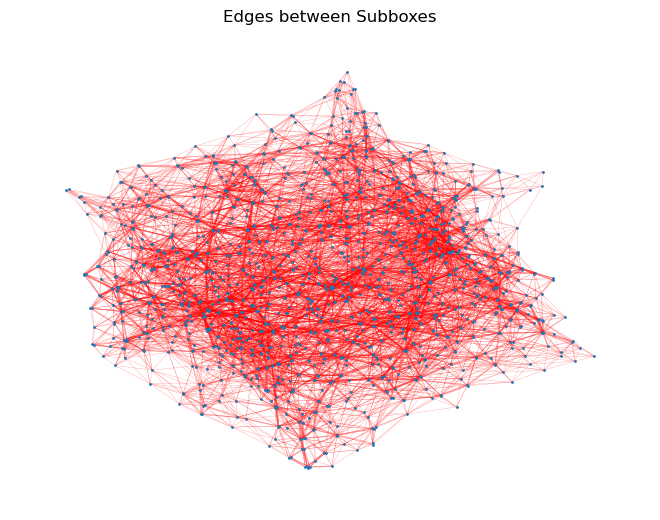

In [101]:
#Uncomment the following to visualize the edges
import networkx as nx
import matplotlib.pyplot as plt


# Create graph from all edges
G = nx.Graph(edges)
H = nx.Graph(new_edges)
H.add_edges_from(edges)

# Plot the graphs
# plt.figure(figsize=(12, 8))
# plt.subplot(121)   
# nx.draw(G, with_labels=False, node_size=1, edge_color='red', width=0.1)
# plt.title("Edges within Subbox")
# plt.subplot(122)
nx.draw(H, with_labels=False, node_size=1, edge_color='red', width=0.1)
plt.title("Edges between Subboxes")

In [102]:
## Step 4: assign weightage to each edge
total_edges = edges + new_edges # Can change this later to only have "edges", I made new_edges to show the step by step progression of the number of edges

for (p,q) in total_edges: 
    molecule_1 = centre.loc[centre["res_id"] == p, ['x','y','z']].values[0]
    molecule_2 = centre.loc[centre["res_id"] == q, ['x','y','z']].values[0]
    distance = float(np.sum(np.square(np.add(molecule_1,molecule_2))) ** (1/2))
    total_edges[total_edges.index((p,q))] = (p,q, distance)

total_edges

[(977, 1171, 7.353702638807202),
 (1206, 1330, 3.9726369391123573),
 (55, 790, 5.820063917174793),
 (356, 857, 11.77961494489527),
 (586, 1341, 16.093278053274293),
 (984, 1343, 21.189524923886328),
 (510, 1485, 7.627517059961256),
 (27, 796, 14.245126499964822),
 (101, 879, 19.59778616323793),
 (248, 959, 7.3614333522759),
 (688, 797, 13.031673290487296),
 (326, 537, 17.33273040377655),
 (1186, 1415, 21.49731728611735),
 (500, 1010, 9.390200463781378),
 (605, 854, 10.6938441871948),
 (17, 448, 19.89412532633692),
 (637, 1236, 22.084800276434468),
 (45, 1190, 14.645694128309522),
 (765, 1201, 13.949921299061153),
 (347, 980, 17.473401357491905),
 (347, 1112, 17.38854339788126),
 (980, 1112, 17.23585038517102),
 (250, 861, 19.869285209840843),
 (180, 657, 15.2823915340499),
 (180, 1012, 15.895380689055548),
 (657, 1012, 15.9162444769487),
 (134, 880, 19.916916289928015),
 (134, 1280, 20.169720659939742),
 (880, 1280, 20.00012364961777),
 (182, 810, 22.4656866465283),
 (266, 316, 18.3140

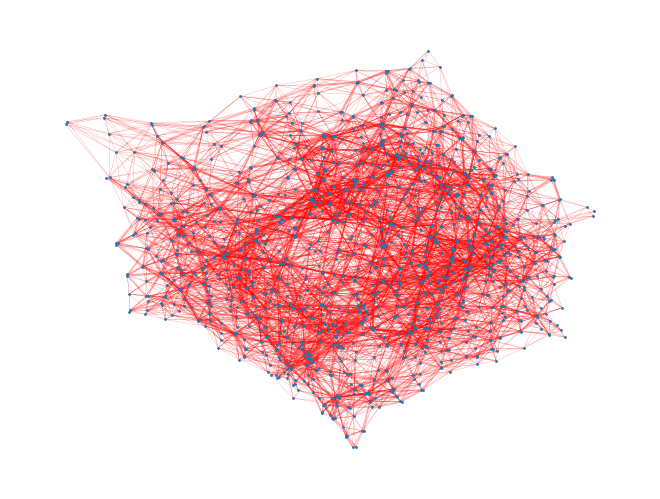

In [103]:
import networkx as nx
Weighted_graph = nx.Graph()
Weighted_graph.add_weighted_edges_from(total_edges)
nx.draw(Weighted_graph, with_labels=False, node_size=1, edge_color='red', width=0.1)